# Generating Power-Spectral Slope data Debugging

**Purpose**: Code for debugging the Power-Spectral Slope data generator

**Luke Colosi | lcolosi@ucsd.edu**

Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import cmocean.cm as cmo

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
#from spectra import generate_powerlaw_data

In [ ]:
#--- Generate 1D data from a power law spectrum ---# 
def generate_powerlaw_data(N=2**12, alpha=2.0, random_state=None, dt=1.0):
    """
    Generate a synthetic data record with a power-law spectrum S(f) ~ f^(-alpha).
    Normalized PSD so that the variance of the time series matches Parseval's theorem.

    Parameters
    ----------
    N : int
        Length of the time series (preferably a power of 2 for FFT efficiency).
    alpha : float
        Spectral slope (e.g., alpha=0 white noise, alpha=1 pink noise, alpha=2 red noise).
    random_state : int or None
        Seed for reproducibility.
    dt : float
        Sampling interval (arbitrary units).

    Returns
    -------
    t : ndarray
        Time or spatial array (0..N-1).
    x : ndarray
        Generated data record.
    f : ndarray
        Frequencies corresponding to PSD (cycles per unit)
    psd : ndarray
        Power spectral density of the generated series.
    """

    # Import libraries
    import numpy as np
    from scipy.signal import detrend

    #-----------------------------------------------------------------------
    # STEP 1 - Set frequencies, amplitudes, and phases for Fourier Coefficients 
    #-----------------------------------------------------------------------

    # Create a new random number generator object for phases (for reproducable results)
    rng = np.random.default_rng(random_state)

    # Set frequencies for FFT (nonnegative with length N//2 + 1 from 0 to nyquist frequency)
    freqs = np.fft.rfftfreq(N, d=dt)  # assume unit sampling interval

    # Avoid divide-by-zero at f=0
    freqs[0] = 1e-6  

    # Power-law amplitude scaling 
    amplitude = freqs**(-alpha / 2.0)

    ###################
    # Note
    # ----
    # We need scale the Fourier amplitudes so that when squared (for computing the power spectrum), 
    # they follow the desired f^(-alpha) power law. Recall the power spectrum is square of the 
    # Fourier coefficients
    # 
    # S(f) = |X(f)|^2
    # 
    # Therefore, in order for S(f) ~ f^(-alpha), we need: 
    # 
    # |X(f)|^2 = f^(-alpha)  ->  |X(f)| = (f^(-alpha))^1/2 = f^(-alpha/2)
    ###################

    # Generate random phases uniformly distributed [0, 2pi)
    phases = rng.uniform(0, 2*np.pi, size=freqs.shape)

    ###################
    # Note
    # ----
    # The power spectrum S(f) tells us how much variance lives at each frequency but it does
    # not tell us what the waveform looks like. To actually construct a time series, you need
    # the complex Fourier coefficients: 
    # 
    # X(f) = |X(f)| e^(i phi(f)) = |X(f)| (cos(phi(f)) + i * sin(phi(f)))
    # 
    # where |X(f)| are the amplitudes of the Fourier coefficients and phi(f) are the phases. 
    # The phases must be randomized to ensure that energy is spread out in time in a
    # realistic, stochastic way. That is, to ensure create a statistically stationary time series
    # that has no artificial coherence (e.g., if the phases were fixed at the same value, at 
    # at the beginning of the record, there would be a perfectly aligned sum of sinusoids that
    # might look like a standing wave). 
    ###################

    #-----------------------------------------------------------------------
    # STEP 2 - Compute Fourier Coefficients and build spectrum 
    #-----------------------------------------------------------------------

    # Complex Fourier coefficients
    fourier_coeffs = amplitude * np.exp(1j * phases)

    # Enforce reality conditions
    fourier_coeffs[0] = amplitude[0]               # DC component real
    if N % 2 == 0:
        fourier_coeffs[-1] = amplitude[-1]         # Nyquist real

    #-----------------------------------------------------------------------
    # STEP 3 - Compute data record
    #-----------------------------------------------------------------------

    # Generate time or space vector
    t = np.arange(N)

    # Inverse FFT to time or space domain
    x = np.fft.irfft(fourier_coeffs, n=N)

    # Normalize to unit variance
    x = x / np.std(x)  
    
    ###################
    # Note
    # ----
    # We normalize to unit variance so the data record's realizations are comparable. 
    # We can then rescale to whatever variance we need based on observations. 
    ###################

    #-----------------------------------------------------------------------
    # STEP 4 - Compute Variance preserving PSD
    #-----------------------------------------------------------------------

    # Set spectral parameters
    df = 1 / (N * dt)
    L = N // 2 + 1 if N % 2 == 0 else (N + 1) // 2

    # Detrend time series
    x_dt = x - np.mean(x) #detrend(x)
    
    # Compute FFT of the time series
    fft_data = np.fft.fft(x_dt) 
    
    # Take squared modulus of the Fourier coefficients
    amp = np.abs(fft_data) ** 2
    
    # Grab positive frequencies for single-sided PSD
    amp_pos = amp[:L]
    
    # Double the amplitude for positive frequencies to conserve variance
    if N % 2 == 0:
        amp_pos[1:-1] *= 2
    else:
        amp_pos[1:] *= 2
    
    # Normalize power spectral density
    psd = amp_pos / (N**2 * df)

    return t, x, freqs, psd

In [ ]:
#--- Generate 1D data from a power law spectrum ---# 
def generate_powerlaw_data_OG(N=2**12, alpha=2.0, random_state=None, dt=1.0):
    """
    Generate a synthetic data record with a power-law spectrum S(f) ~ f^(-alpha).
    Normalized PSD so that the variance of the time series matches Parseval's theorem.

    Parameters
    ----------
    N : int
        Length of the time series (preferably a power of 2 for FFT efficiency).
    alpha : float
        Spectral slope (e.g., alpha=0 white noise, alpha=1 pink noise, alpha=2 red noise).
    random_state : int or None
        Seed for reproducibility.
    dt : float
        Sampling interval (arbitrary units).

    Returns
    -------
    t : ndarray
        Time or spatial array (0..N-1).
    x : ndarray
        Generated data record.
    f : ndarray
        Frequencies corresponding to PSD (cycles per unit)
    psd : ndarray
        Power spectral density of the generated series.
    """

    # Import libraries
    import numpy as np
    from scipy.signal import detrend

    #-----------------------------------------------------------------------
    # STEP 1 - Set frequencies, amplitudes, and phases for Fourier Coefficients 
    #-----------------------------------------------------------------------

    # Create a new random number generator object for phases (for reproducable results)
    rng = np.random.default_rng(random_state)

    # Set frequencies for FFT (nonnegative with length N//2 + 1 from 0 to nyquist frequency)
    freqs = np.fft.rfftfreq(N, d=dt)  # assume unit sampling interval

    # Avoid divide-by-zero at f=0
    freqs[0] = 1e-6  

    # Power-law amplitude scaling 
    amplitude = freqs**(-alpha / 2.0)

    ###################
    # Note
    # ----
    # We need scale the Fourier amplitudes so that when squared (for computing the power spectrum), 
    # they follow the desired f^(-alpha) power law. Recall the power spectrum is square of the 
    # Fourier coefficients
    # 
    # S(f) = |X(f)|^2
    # 
    # Therefore, in order for S(f) ~ f^(-alpha), we need: 
    # 
    # |X(f)|^2 = f^(-alpha)  ->  |X(f)| = (f^(-alpha))^1/2 = f^(-alpha/2)
    ###################

    # Generate random phases uniformly distributed [0, 2pi)
    phases = rng.uniform(0, 2*np.pi, size=freqs.shape)

    ###################
    # Note
    # ----
    # The power spectrum S(f) tells us how much variance lives at each frequency but it does
    # not tell us what the waveform looks like. To actually construct a time series, you need
    # the complex Fourier coefficients: 
    # 
    # X(f) = |X(f)| e^(i phi(f)) = |X(f)| (cos(phi(f)) + i * sin(phi(f)))
    # 
    # where |X(f)| are the amplitudes of the Fourier coefficients and phi(f) are the phases. 
    # The phases must be randomized to ensure that energy is spread out in time in a
    # realistic, stochastic way. That is, to ensure create a statistically stationary time series
    # that has no artificial coherence (e.g., if the phases were fixed at the same value, at 
    # at the beginning of the record, there would be a perfectly aligned sum of sinusoids that
    # might look like a standing wave). 
    ###################

    #-----------------------------------------------------------------------
    # STEP 2 - Compute Fourier Coefficients and build spectrum 
    #-----------------------------------------------------------------------

    # Compute Fourier coefficients (Euler formula expanded)
    real_part = amplitude * np.cos(phases)
    imag_part = amplitude * np.sin(phases)
    fourier_coeffs = real_part + 1j * imag_part

    # Build full spectrum (Hermitian symmetry to ensure real signal in the time/space domain)
    full_spectrum = np.zeros(N, dtype=complex)
    full_spectrum[:len(freqs)] = fourier_coeffs
    full_spectrum[len(freqs):] = np.conj(fourier_coeffs[1:-1][::-1])

    #-----------------------------------------------------------------------
    # STEP 3 - Compute data record
    #-----------------------------------------------------------------------

    # Generate time or space vector
    t = np.arange(N)

    # Inverse FFT to time or space domain
    x = np.fft.ifft(full_spectrum).real
    x = x / np.std(x)  
    
    ###################
    # Note
    # ----
    # We normalize to unit variance so the data record's realizations are comparable. 
    # We can then rescale to whatever variance we need based on observations. 
    ###################

    #-----------------------------------------------------------------------
    # STEP 4 - Compute Variance preserving PSD
    #-----------------------------------------------------------------------

    # Set spectral parameters
    df = 1 / (N * dt)
    L = N // 2 + 1 if N % 2 == 0 else (N + 1) // 2

    # Detrend time series
    #x_dt = detrend(x)
    
    # Compute FFT of the time series
    fft_data = np.fft.fft(x) 
    
    # Take squared modulus of the Fourier coefficients
    amp = np.abs(fft_data) ** 2
    
    # Grab positive frequencies for single-sided PSD
    amp_pos = amp[:L]
    
    # Double the amplitude for positive frequencies to conserve variance
    if N % 2 == 0:
        amp_pos[1:-1] *= 2
    else:
        amp_pos[1:] *= 2
    
    # Normalize power spectral density
    psd = amp_pos / (N**2 * df)

    return t, x, freqs, psd

Set plotting parameters

In [2]:
fontsize = 16

# Set font and fontsize
os.environ["PATH"] = "/usr/local/texlive/2022/bin/universal-darwin:" + os.environ["PATH"]
plt.rcParams.update({
    "font.size": fontsize,                          # Fontsize
    "text.usetex": True,                           # Use LaTeX for all text
    "font.family": "serif",                         # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
})

Set analysis parameters

In [5]:
# Set time parameters
dt = 1                # Time interval (hours)
T  = 2*365*24         # Duration of record (hours) 
N  = int(T/dt)        # Number of data points in our record
random_seed = 42      # Set random seed for reproducibility

# Set power-law parameters
alpha = 3             # Prescribed spectral slopes

Generate power-spectra law data

In [6]:
t, x, f, psd = generate_powerlaw_data(N=N, alpha=alpha, random_state=random_seed, dt=dt)
t_og, x_og, f_og, psd_og = generate_powerlaw_data_OG(N=N, alpha=alpha, random_state=random_seed, dt=dt)

Plot data in time and frequency domain 

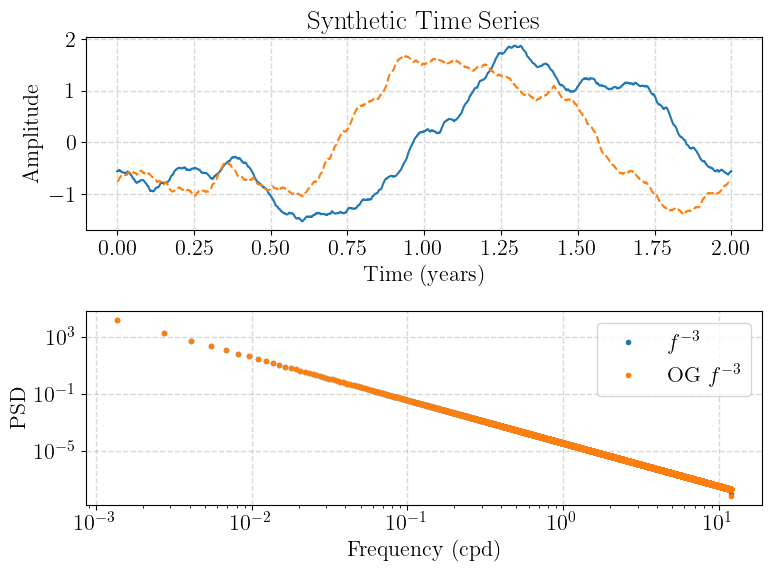

In [8]:
# Convert units of frequency and time
f_cpd = f * 24
t_year = t * (1/24)*(1/365)
f_og_cpd = f_og * 24
t_og_year = t_og * (1/24)*(1/365)

# Create figure
fig,axes = plt.subplots(2,1,figsize=(8,6))
ax1,ax2 = axes.flatten()

#--- Subplot 1 ---# 
ax1.plot(t_year, x - np.mean(x), color='tab:blue')
ax1.plot(t_og_year, x_og - np.mean(x_og), color='tab:orange', ls='--')

#--- Subplot 1 ---# 
ax2.loglog(f_cpd[1:], psd[1:], marker= '.', ls='none', color='tab:blue', label=r"$f^{-" + str(alpha) + r"}$")
ax2.loglog(f_og_cpd[1:], psd_og[1:], marker= '.', ls='none', color='tab:orange', label=r"OG $f^{-" + str(alpha) + r"}$")

# Set axis attributes
ax1.set_title('Synthetic Time Series')
ax1.set_xlabel("Time (years)")
ax1.set_ylabel("Amplitude")
ax1.grid(ls='--',lw=1.0,alpha=0.5)

# Set axis attributes
ax2.set_xlabel("Frequency (cpd)")
ax2.set_ylabel("PSD")
ax2.legend()
ax2.grid(ls='--',lw=1.0,alpha=0.5)
#ax2.set_xlim(10,14)
#ax2.set_ylim(1e-9,1e-7)

# Display figure
plt.tight_layout()
plt.show()

### Why the Nyquist-frequency PSD bin appears systematically lower

The slight reduction in power at the highest resolved frequency (the Nyquist frequency) is a fundamental statistical property of discrete Fourier transforms, not an artifact of the synthetic data generator. For a real-valued time series $( x(t) )$, Fourier coefficients at interior frequencies $( 0 < f < f_N )$ are complex-valued and consist of two independent Gaussian degrees of freedom (real and imaginary parts). Consequently, the corresponding periodogram estimates follow a chi-square distribution with two degrees of freedom, $( \chi^2_2 )$, and have variance equal to the square of the underlying spectral density. In contrast, the Nyquist-frequency coefficient (at $( f = f_N )$) must be purely real to satisfy Hermitian symmetry. As a result, it has only one independent Gaussian degree of freedom and its power follows a $( \chi^2_1 )$ distribution. While the expected value of the Nyquist-bin power remains unbiased (i.e., $( \mathbb{E}[P(f_N)] = S(f_N) )$), its variance is reduced by a factor of two relative to interior frequencies. For a single realization—particularly for steep power-law spectra where high-frequency variance is already small—this reduced statistical variance manifests visually as a slight “dip” in the Nyquist PSD bin. Ensemble averaging or spectral averaging methods (e.g., Welch or multitaper estimates) eliminate this effect, confirming that it reflects intrinsic Fourier statistics rather than a flaw in the data-generation procedure.


If we were to compute a ensemble average (Welch method), this artifact would be removed. 

In [4]:
# Set time parameters
dt = 1                # Time interval (hours)
T  = 2*365*24         # Duration of record (hours) 
N  = int(T/dt)        # Number of data points in our record
random_state = 42      # Set random seed for reproducibility

# Set power-law parameters
alpha = 3             # Prescribed spectral slopes

### Step 1 - Set frequencies, amplitudes, and phases for Fourier Coefficients 

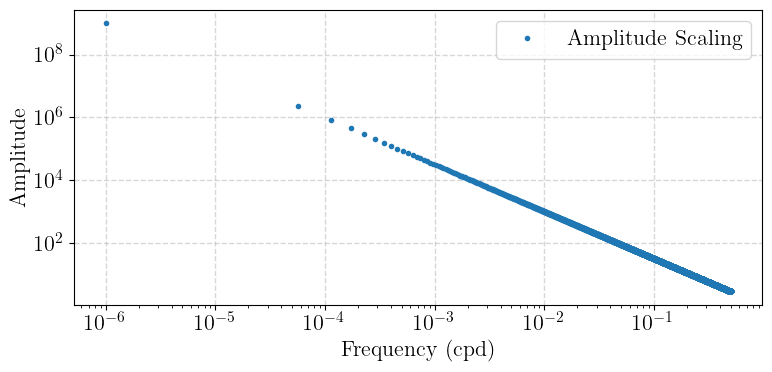

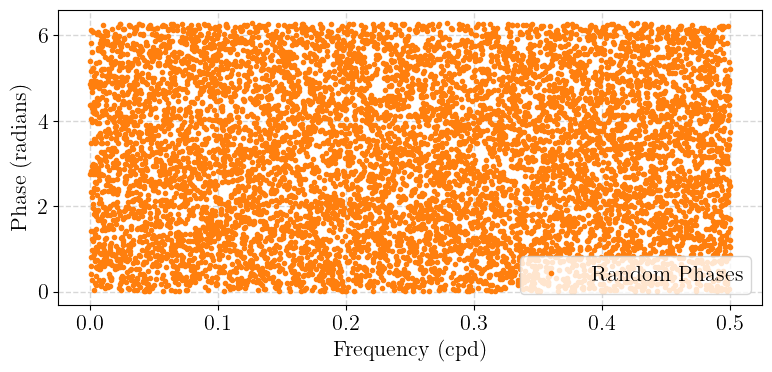

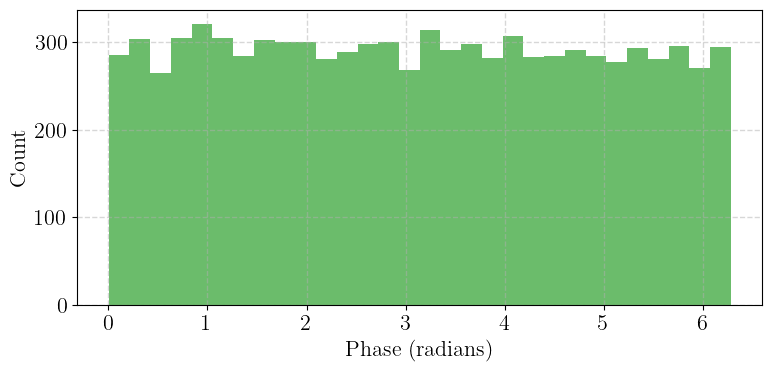

In [9]:
#-----------------------------------------------------------------------
# STEP 1 - Set frequencies, amplitudes, and phases for Fourier Coefficients 
#-----------------------------------------------------------------------

# Create a new random number generator object for phases (for reproducable results)
rng = np.random.default_rng(random_state)

# Set frequencies for FFT (nonnegative with length N//2 + 1 from 0 to nyquist frequency)
freqs = np.fft.rfftfreq(N, d=dt)  # assume unit sampling interval

# Avoid divide-by-zero at f=0
freqs[0] = 1e-6  

# Power-law amplitude scaling 
amplitude = freqs**(-alpha / 2.0)

# Generate random phases uniformly distributed [0, 2pi)
phases = rng.uniform(0, 2*np.pi, size=freqs.shape)

# Plot amplitude
fig, ax = plt.subplots(figsize=(8,4))
ax.loglog(freqs, amplitude, marker='.', ls='none', color='tab:blue', label='Amplitude Scaling')
ax.set_xlabel('Frequency (cpd)')
ax.set_ylabel('Amplitude')
ax.grid(ls='--', lw=1.0, alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

# Plot phases
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(freqs, phases, marker='.', ls='none', color='tab:orange', label='Random Phases')
ax.set_xlabel('Frequency (cpd)')
ax.set_ylabel('Phase (radians)')
ax.grid(ls='--', lw=1.0, alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

# plot histogram of phases
fig, ax = plt.subplots(figsize=(8,4))
ax.hist(phases, bins=30, color='tab:green', alpha=0.7)
ax.set_xlabel('Phase (radians)')
ax.set_ylabel('Count')
ax.grid(ls='--', lw=1.0, alpha=0.5)
plt.tight_layout()
plt.show()      

### Step 2 - Compute Fourier Coefficients and build spectrum 

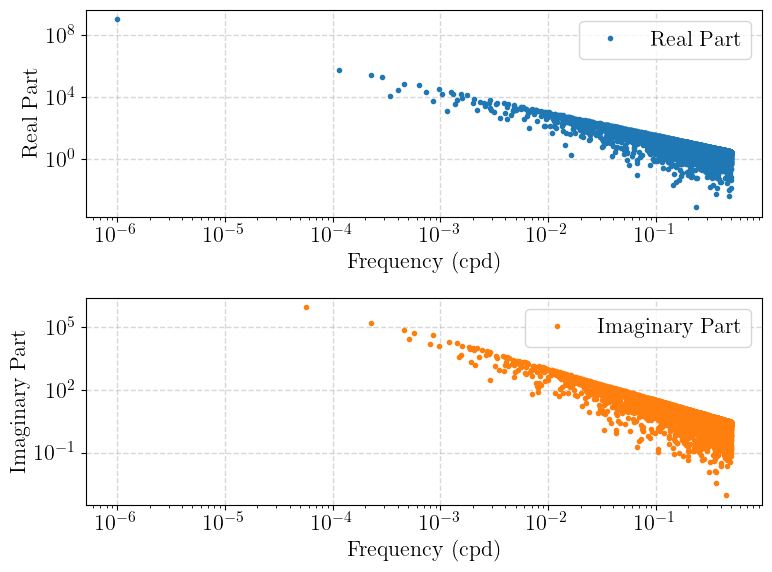

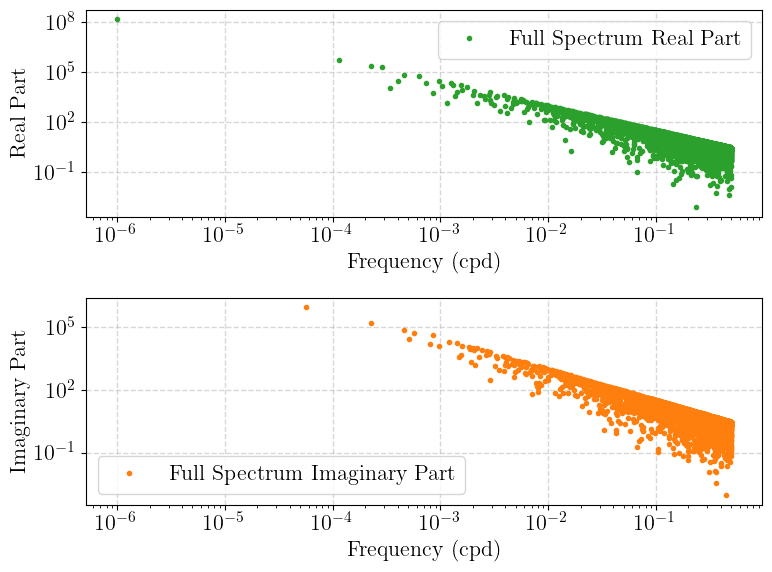

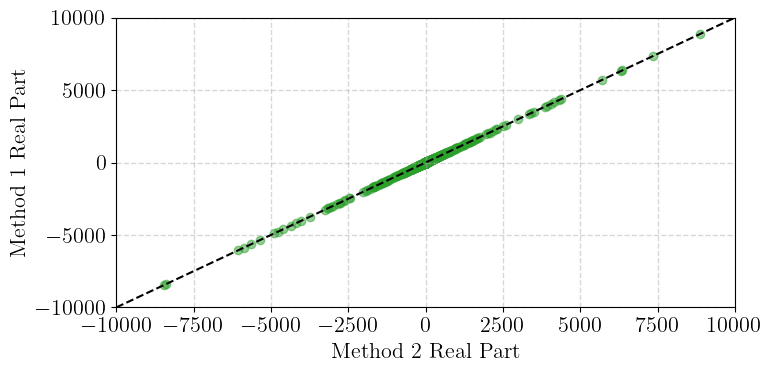

In [17]:
#--- Method 1 ---# 

# Compute Fourier coefficients (Euler formula expanded)
real_part = amplitude * np.cos(phases)
imag_part = amplitude * np.sin(phases)
fourier_coeffs = real_part + 1j * imag_part

# Build full spectrum (Hermitian symmetry to ensure real signal in the time/space domain)
full_spectrum = np.zeros(N, dtype=complex)
full_spectrum[:len(freqs)] = fourier_coeffs
full_spectrum[len(freqs):] = np.conj(fourier_coeffs[1:-1][::-1])

#--- Method 2 ---#

# Complex Fourier coefficients
fourier_coeffs = amplitude * np.exp(1j * phases)

# Enforce reality conditions
fourier_coeffs[0] = amplitude[0]               # DC component real
if N % 2 == 0:
    fourier_coeffs[-1] = amplitude[-1]         # Nyquist real

# Plot real and imaginary parts of Fourier coefficients
fig, axes = plt.subplots(2,1, figsize=(8,6))
ax1, ax2 = axes.flatten()
ax1.loglog(freqs, fourier_coeffs.real, marker='.', ls='none', color='tab:blue', label='Real Part')
ax2.loglog(freqs, fourier_coeffs.imag, marker='.', ls='none', color='tab:orange', label='Imaginary Part')     
ax1.set_xlabel('Frequency (cpd)')
ax1.set_ylabel('Real Part')
ax1.grid(ls='--', lw=1.0, alpha=0.5)
ax1.legend()
ax2.set_xlabel('Frequency (cpd)')
ax2.set_ylabel('Imaginary Part')
ax2.grid(ls='--', lw=1.0, alpha=0.5)
ax2.legend()
plt.tight_layout()
plt.show()

# Plot the full_spectrum real and imaginary parts
fig, axes = plt.subplots(2,1,figsize=(8,6))
ax1, ax2 = axes.flatten()
ax1.loglog(freqs, full_spectrum[:len(freqs)].real, marker='.', ls='none', color='tab:green', label='Full Spectrum Real Part')
ax2.loglog(freqs, full_spectrum[:len(freqs)].imag, marker='.', ls='none', color='tab:orange', label='Full Spectrum Imaginary Part')
ax1.set_xlabel('Frequency (cpd)')
ax1.set_ylabel('Real Part')
ax1.grid(ls='--', lw=1.0, alpha=0.5)
ax1.legend()
ax2.set_xlabel('Frequency (cpd)')
ax2.set_ylabel('Imaginary Part')
ax2.grid(ls='--', lw=1.0, alpha=0.5)
ax2.legend()
plt.tight_layout()
plt.show()

# Plot comparison of real parts
fig, ax = plt.subplots(figsize=(8,4))
ax.scatter(fourier_coeffs.real, full_spectrum[:len(freqs)].real, color='tab:green', alpha=0.5)
ax.plot([-1e4,1e4], [-1e4,1e4], color='k', ls='--')
ax.set_xlabel('Method 2 Real Part')
ax.set_ylabel('Method 1 Real Part')
ax.set_xlim([-1e4,1e4])
ax.set_ylim([-1e4,1e4])
ax.grid(ls='--', lw=1.0, alpha=0.5)
plt.tight_layout()
plt.show()  

### Step 3 - Compute data record

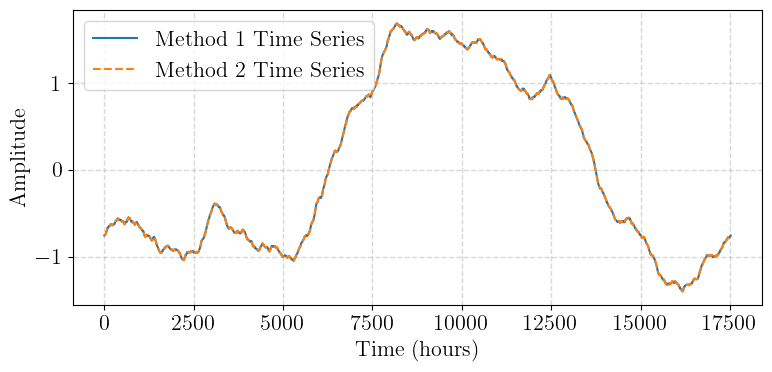

In [19]:
# Generate time or space vector
t = np.arange(N)

# Inverse FFT to time or space domain
x2 = np.fft.irfft(fourier_coeffs, n=N)
x1 = np.fft.ifft(full_spectrum).real

# Normalize to unit variance
x2 = x2 / np.std(x2)  
x1 = x1 / np.std(x1)

# Plot comparison of time series
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(t, x1 - np.mean(x1), color='tab:blue', label='Method 1 Time Series')
ax.plot(t, x2 - np.mean(x2), color='tab:orange', ls='--', label='Method 2 Time Series')
ax.set_xlabel('Time (hours)')
ax.set_ylabel('Amplitude')
ax.legend()
ax.grid(ls='--', lw=1.0, alpha=0.5)
plt.tight_layout()
plt.show()  

In [20]:
np.mean(x1)

np.float64(41.70376147969617)

In [22]:
np.mean(x2)

np.float64(278.1130303207382)